## (70 points possible)
Also needs the data file cereal.csv.

# Problem 1:  Graphing (10 pts [5, 5])


a, 5 pts) The lists provided give the 2025 GDPs of the US, China, Germany, India, Japan, and the UK (in trillions of dollars), and also their populations in that same order (in millions). Plot these with matplotlib.pyplot as a scatter plot, with population as the X axis and GDP as the Y axis.  Also, label the x and y axes using plt.xlabel() and plt.ylabel().

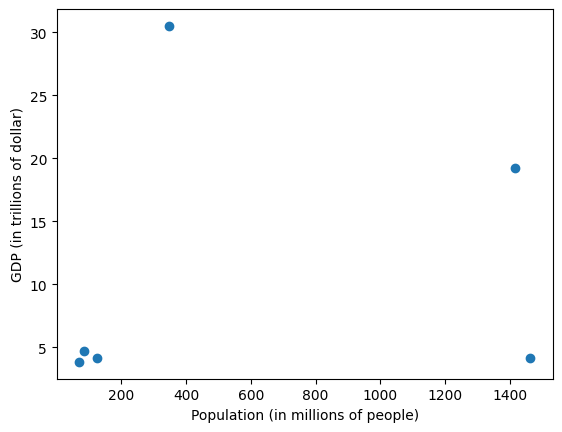

In [2]:
gdps = [30.51, 19.23, 4.74, 4.19, 4.18, 3.84]
pops = [347, 1416, 84, 1464, 123, 70]

import matplotlib.pyplot as plt

plt.scatter(pops, gdps)
plt.xlabel("Population (in millions of people)")
plt.ylabel("GDP (in trillions of dollar)")

plt.show()



b, 5pts) Plot the same graph (including the axis labels) again but with additional trendline in red of y = 0.00275x + 9.5, plotted as a line graph on top of the original points, which should now be a scatter plot. Hint:  You just need two points of the line to plot the line, one for x=0 and one for x=1600.

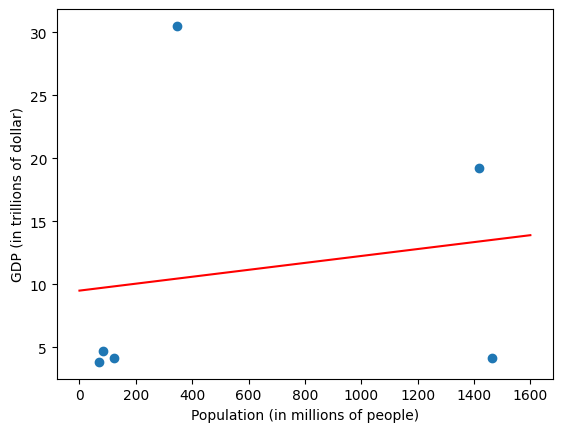

In [3]:
plt.scatter(pops, gdps)
plt.xlabel("Population (in millions of people)")
plt.ylabel("GDP (in trillions of dollar)")

y_values = [0.00275 * 0 + 9.5, 0.00275 * 1600 + 9.5]
x_values = [0, 1600]

plt.plot(x_values, y_values, color='red')
plt.show()

# Problem 2:  Nested loops and numpy arrays (10 pts [5, 5])

3D points can be represented by vectors of 3 coordinates, $\begin{bmatrix}x\\y\\z\end{bmatrix}$.  These in turn can be represented by 3 element numpy arrays.  We can therefore represent a triangle as a matrix with 3 columns, $\begin{bmatrix}x_1 & x_2 & x_3\\y_1 & y_2 & y_3\\z_1 & z_2 & z_3\end{bmatrix}$, which can in turn be represented with a $3 \times 3$ numpy matrix, with the columns representing the points of the triangle.

We could therefore represent a whole 3D model, such as of Woody from *Toy Story*, as a list of these matrices, with each little triangle a part of a surface to render.

And we could therefore represent a whole scene as a list-of-lists, where each list represents one of these 3D models.

In [4]:
import numpy as np

point1 = np.array([[0], [0], [0]])
point2 = np.array([[-1], [0], [0]])
point3 = np.array([[0], [1], [0]])
point4 = np.array([[0], [0], [1]])

triangle1 = np.hstack((point1, point4, point2))  # hstack concatenates columns side-by-side
triangle2 = np.hstack((point2, point1, point3))
triangle3 = np.hstack((point4, point1, point3))
triangle4 = np.hstack((point4, point2, point3))

model1 = [triangle1, triangle2, triangle3, triangle4]
model1

[array([[ 0,  0, -1],
        [ 0,  0,  0],
        [ 0,  1,  0]]),
 array([[-1,  0,  0],
        [ 0,  0,  1],
        [ 0,  0,  0]]),
 array([[0, 0, 0],
        [0, 0, 1],
        [1, 0, 0]]),
 array([[ 0, -1,  0],
        [ 0,  0,  1],
        [ 1,  0,  0]])]

a, 5 points) Write code that creates a new model, model2, that is the same as model1 but rotated 90 degrees around the x axis.  Matrix-multiplying $MT$ (M @ T in Python) will do this, where M is the rotation matrix and T is the triangle's matrix.  The rotation matrix is $\begin{bmatrix}1 & 0 & 0 \\ 0 & 0 & -1 \\ 0 & 1 & 0\end{bmatrix}$.  Inspect your results to see whether they make sense; the x coordinate shouldn't change, for example.  (Conventionally, x is toward the viewer, y is to the right, z is up, and this rotation should go counterclockwise.)

In [5]:
import numpy as np
rotation_matrix = np.array([[1, 0, 0], [0, 0, -1], [0, 1, 0]])
model2 = rotation_matrix @ model1
model2

array([[[ 0,  0, -1],
        [ 0, -1,  0],
        [ 0,  0,  0]],

       [[-1,  0,  0],
        [ 0,  0,  0],
        [ 0,  0,  1]],

       [[ 0,  0,  0],
        [-1,  0,  0],
        [ 0,  0,  1]],

       [[ 0, -1,  0],
        [-1,  0,  0],
        [ 0,  0,  1]]])

b, 5 points) Write a function shiftx(models, delta) that adds *delta* to all the x coordinates of every triangle in every model in a list of models, *models*, returning the modified list of models.  

Note that one way to do this is to create a 3x3 matrix $\begin{bmatrix} \delta & \delta & \delta \\ 0 & 0 & 0 \\ 0 & 0 & 0\end{bmatrix}$, where $\delta$ is the delta argument, and add it to each of the triangle matrices.


In [6]:
def shiftx(models, delta):
  delta_matrix = np.array([[delta, delta, delta], [0, 0, 0], [0, 0, 0]])
  shifted_model = []
  for m in models:
    shifted_matrix = delta_matrix + m
    shifted_model.append(shifted_matrix)
  return shifted_model

In [7]:
shiftx([model1, model2], 10) # Expect [[array([[10, 10, 9], [0, 0, 0], [0, 1, 0]]), ...]]

[array([[[10, 10,  9],
         [ 0,  0,  0],
         [ 0,  1,  0]],
 
        [[ 9, 10, 10],
         [ 0,  0,  1],
         [ 0,  0,  0]],
 
        [[10, 10, 10],
         [ 0,  0,  1],
         [ 1,  0,  0]],
 
        [[10,  9, 10],
         [ 0,  0,  1],
         [ 1,  0,  0]]]),
 array([[[10, 10,  9],
         [ 0, -1,  0],
         [ 0,  0,  0]],
 
        [[ 9, 10, 10],
         [ 0,  0,  0],
         [ 0,  0,  1]],
 
        [[10, 10, 10],
         [-1,  0,  0],
         [ 0,  0,  1]],
 
        [[10,  9, 10],
         [-1,  0,  0],
         [ 0,  0,  1]]])]

# Problem 3: Rotations in 2D (22 points [4, 3, 5, 2, 5, 3])

Recall from lecture that matrix-vector multiplication transforms one vector into another vector. This is an important operation, for instance, when rotating objects in a computer game. There is a specific 2D matrix for rotating vectors of length 2 (points in the xy plane) counterclockwise by an angle $\theta$ in radians. The matrix has the form:

$$
G =
\begin{pmatrix}
\cos{\theta} & -\sin{\theta} \\
\sin{\theta} & \cos{\theta}
\end{pmatrix}
$$.

Computing the matrix vector product $Gv$ rotates the vector $v$ counterclockwise by the angle $\theta$.

In this problem you need to code several functions that will allow you to rotate a vector by a specified degree. You will then write code to visualize how this vector rotates in the plane.

a, 4 pts) Write a function `create_rotation_matrix()` that takes in an angle in degrees. The output should be the rotation matrix corresponding to this angle using the above formula. Remember that to convert from degrees to radians you multiple by a factor of $\pi/180$. You may use either math or NumPy to import the fucntions $\cos$, $\sin$, and constant $\pi$. Test your function using an angle of $45^{\circ}$ and print the returned matrix, which should be np.arrray([[ 0.70710678 -0.70710678],[ 0.70710678  0.70710678]]).

In [8]:
def create_rotation_matrix(angle):
  angle_rad = angle * (np.pi/180)
  x11 = np.cos(angle_rad)
  x12 = np.sin(angle_rad) * (-1)
  x21 = np.sin(angle_rad)
  x22 = np.cos(angle_rad)
  rotation_matrix = np.array([[x11, x12], [x21, x22]])
  return rotation_matrix

create_rotation_matrix(45)

array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]])

b, 3 pts) Using your `create_rotation_matrix` function, write a new function `rotate_vector(vector, angle)` that takes as input a 2D vector and an angle in degrees, and returns the rotated vector. (Do not call a rotation function to do the rotation; use your matrix.)  Test your function using the angle $45^{\circ}$ and the vector $[1, 0]$, printing the rotated vector.

In [9]:
def rotate_vector(vector, angle):
  rotation = create_rotation_matrix(angle)
  rotated_vector = rotation @ vector
  return rotated_vector

test_vector = np.array([1, 0])
rotate_vector(test_vector, 45)

array([0.70710678, 0.70710678])

c, 5 pts) We now have functions to create a rotation matrix based on an angle and a function to rotate a vector by that angle. Write a new function called `rotate_vectors(vector, angles)` that takes a vector and a list of angles in degrees. This function should return a list containing the original input vector rotated by each angle in the list of angles. Test this function using the vector `[1, 0]` and the list of angles `[0, 30, 60, 90, 120, 150, 180]`. Print the output list of vectors.

In [10]:
def rotate_vectors(vector, angles):
  rotated_list = []
  for a in angles:
    rotated_vector = rotate_vector(vector, a)
    rotated_list.append(rotated_vector)
  return rotated_list

rotate_vectors(np.array([1, 0]), [0, 30, 60, 90, 120, 150, 180])

[array([1., 0.]),
 array([0.8660254, 0.5      ]),
 array([0.5      , 0.8660254]),
 array([6.123234e-17, 1.000000e+00]),
 array([-0.5      ,  0.8660254]),
 array([-0.8660254,  0.5      ]),
 array([-1.0000000e+00,  1.2246468e-16])]

d 2 pts) To visualize a vector [x, y] in the plane, we can use matplotlib to plot a line from the origin [0, 0] to the point [x, y]. Given the vector [-1, 1], plot a red line representing this vector.

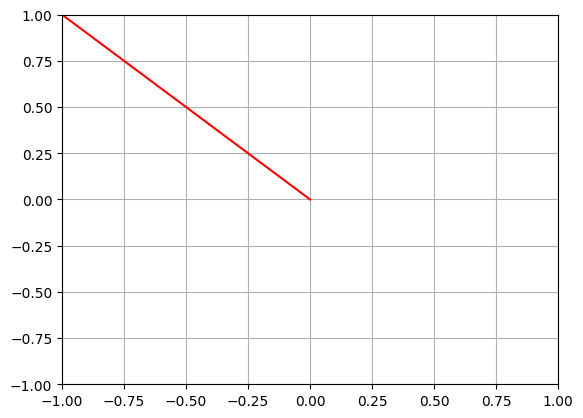

In [11]:
import matplotlib.pyplot as plt
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid()
plt.plot(np.array([0, -1]), np.array([0, 1]), color='red')
plt.show()

e, 5 pts) We want to visualize the rotation of our initial vector. To do this write a helper function called `extract_coordinates(vectors)` which takes as input a list of 2D vectors. This function should return 2 numpy arrays that contain the x-coordinates and y-coordinates, respectively. Test this function using your vector of outputs from the previous cell. Print out the x-coordinates and the y-coordinates.

In [12]:
def extract_coordinates(vectors):
  v_array = np.array(vectors)
  x_array = v_array[:, 0]
  y_array = v_array[:, 1]
  return x_array, y_array
v_test = [[0, 0], [-1, 1]]
x, y = extract_coordinates(v_test)
print(x)
print(y)

[ 0 -1]
[0 1]


f, 3 pts) Let's put everything together now to visualize our rotations. You are given a starting vector `[1, 0]` and the following list of angles `[0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]`. Use your previous functions to get the x- and y-coordinates from `extract_coordinates`.  Then plot the rotated vectors in the different colors specified by the `colors` array.

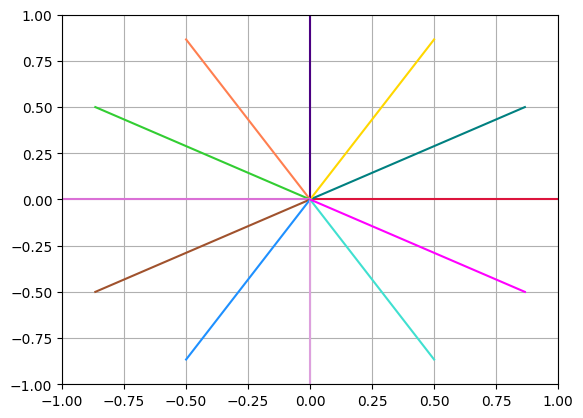

In [17]:
import matplotlib.pyplot as plt
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.grid()
colors = [
    "crimson", "teal", "gold", "indigo", "coral",
    "limegreen", "orchid", "sienna", "dodgerblue", "plum",
    "turquoise", "magenta"
]

vector = np.array([1, 0])
angles = [0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330]

# TODO Use your previously created functions to get a list of x and y coordinates of the rotated vectors
rotated_vectors = rotate_vectors(vector, angles)
x_coords, y_coords = extract_coordinates(rotated_vectors)


for i, xy in enumerate(zip(x_coords, y_coords)):
    # TODO Fill in the correct plot command to plot the xy coordinates of each rotated vector
    plt.plot([0, xy[0]], [0, xy[1]], color=colors[i])

# Problem 4:  Cereal (28 pts [1,1,2,3,3,3,1,6,8])

Download the cereal.csv file from the same place you downloaded this assignment; it's a dataset on 80 different cereal products from [Kaggle](https://www.kaggle.com/datasets/crawford/80-cereals?resource=download).

In [18]:
import pandas as pd

In [19]:
# If using Google Colab, upload cereal.csv here

from google.colab import files
uploaded = files.upload()

Saving cereal.csv to cereal.csv


In [20]:
df = pd.read_csv('cereal.csv', index_col='name')
df.head()

,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
name,,,,,,,,,,,,,,,
100% Bran,N,C,70,4,1,130,10.0,5.0,6,280,25,3,1.0,0.33,68.402973
100% Natural Bran,Q,C,120,3,5,15,2.0,8.0,8,135,0,3,1.0,1.00,33.983679
All-Bran,K,C,70,4,1,260,9.0,7.0,5,320,25,3,1.0,0.33,59.425505
All-Bran with Extra Fiber,K,C,50,4,0,140,14.0,8.0,0,330,25,3,1.0,0.50,93.704912
Almond Delight,R,C,110,2,2,200,1.0,14.0,8,-1,25,3,1.0,0.75,34.384843


a) 1 pt) Find the mean, standard deviation, minimum value, 25th percentile value, 50th percentile value, 75th percentile value, and maximum value of the `calories`, `sodium`, and `rating` columns.  (Printing these values for other columns too is fine.)  You should refer back to your notes to find a DataFrame method that can do all of this in one call.

In [21]:
print(df[['calories', 'sodium', 'rating']].describe())

         calories      sodium     rating
count   77.000000   77.000000  77.000000
mean   106.883117  159.675325  42.665705
std     19.484119   83.832295  14.047289
min     50.000000    0.000000  18.042851
25%    100.000000  130.000000  33.174094
50%    110.000000  180.000000  40.400208
75%    110.000000  210.000000  50.828392
max    160.000000  320.000000  93.704912


b, 1 pt) Now write a line that prints just the `calories` column's statistics, rather than statistics for all the columns.

In [24]:
print(df['calories'].describe())

count     77.000000
mean     106.883117
std       19.484119
min       50.000000
25%      100.000000
50%      110.000000
75%      110.000000
max      160.000000
Name: calories, dtype: float64


c, 2 pts) From all of the cereals with 110 calories, find the average sodium of these cereals.

In [25]:
avg_sodium = df[df['calories'] == 110]['sodium'].mean()
print(avg_sodium)

192.93103448275863


d, 3 pts) Find the correlation of the numeric variables. Are there any strong positive correlations between any of the data columns and the rating?

In [27]:
correlation = df.corr(numeric_only=True)

print(correlation)


          calories   protein       fat    sodium     fiber     carbo  \
calories  1.000000  0.019066  0.498610  0.300649 -0.293413  0.250681   
protein   0.019066  1.000000  0.208431 -0.054674  0.500330 -0.130864   
fat       0.498610  0.208431  1.000000 -0.005407  0.016719 -0.318043   
sodium    0.300649 -0.054674 -0.005407  1.000000 -0.070675  0.355983   
fiber    -0.293413  0.500330  0.016719 -0.070675  1.000000 -0.356083   
carbo     0.250681 -0.130864 -0.318043  0.355983 -0.356083  1.000000   
sugars    0.562340 -0.329142  0.270819  0.101451 -0.141205 -0.331665   
potass   -0.066609  0.549407  0.193279 -0.032603  0.903374 -0.349685   
vitamins  0.265356  0.007335 -0.031156  0.361477 -0.032243  0.258148   
shelf     0.097234  0.133865  0.263691 -0.069719  0.297539 -0.101790   
weight    0.696091  0.216158  0.214625  0.308576  0.247226  0.135136   
cups      0.087200 -0.244469 -0.175892  0.119665 -0.513061  0.363932   
rating   -0.689376  0.470618 -0.409284 -0.401295  0.584160  0.05

There is a fairly positive correlation between the fiber and the rating. Surprisingly there is a negative correlation with the amount of sugar and the rating.

e, 3 pts) Use matplotlib to make a blue scatter plot of the fiber (x-axis) versus rating (y-axis).

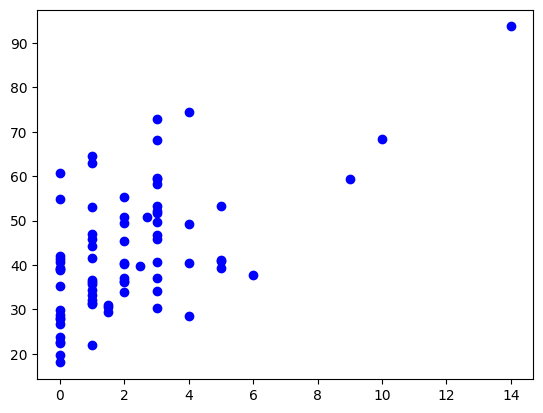

In [28]:
plt.scatter(df['fiber'], df['rating'], color='blue')
plt.show()


f, 3 pts) Standardization is a procedure where a column of data is shifted and scaled to have a mean of 0 and a standard deviation of 1. This can be achieved by subtracting the mean of the column from each entry in the column and then dividing the whole column by the standard deviation. Create a new column called `st_rating` of the standardized ratings. Confirm this new column has a mean of 0 and a standard deviation of 1.

In [29]:
rating_mean = df['rating'].mean()
rating_std = df['rating'].std()
df['st_rating'] = (df['rating'] - rating_mean) / rating_std


In [30]:
print(df['st_rating'].mean()) # Expect 0 or a number on the order of e-16
print(df['st_rating'].std()) # Expect a number very close to 1

-8.651088503572648e-18
1.0000000000000002


g, 1 pt) Create a histogram of the standardized ratings using 25 bins.

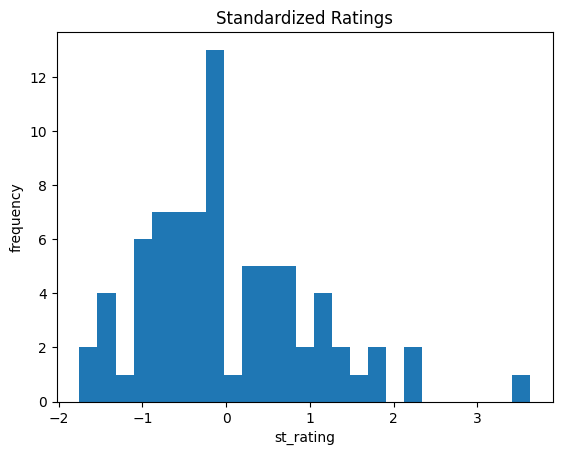

In [33]:
plt.hist(df['st_rating'], bins=25)
plt.xlabel('st_rating')
plt.ylabel('frequency')
plt.title('Standardized Ratings')
plt.show()


h, 6 points) Write a function `name_popularity(df, word)` that iterates through the DataFrame `df` and finds the average `rating` of all cereals that contain `word` in their name.  `word` can be any substring of the name ("in" is a substring of "find") rather than just space-delimited, but case should match. Assume the DataFrame's index contains the names, as with the DataFrame we've been using. Use iterrows() to perform this iteration.

For example, if the string "Corn" appears in the name of 4 cereals, with ratings 30, 60, 70, 40, then the return value is 50.

If the word isn't found in any name, return -1.

In [47]:
def name_popularity(df, word):
  total_rating = 0
  count = 0
  for name, row in df.iterrows():
    if word in name:
      total_rating += row['rating']
      count += 1
  if count == 0:
    return -1
  return total_rating / count


In [48]:
name_popularity(df, 'Corn') # Expect 40.48

40.48272

In [49]:
name_popularity(df, 'Rice') # Expect 47.77

47.77173466666667

In [50]:
name_popularity(df, 'Silly') # Expect -1

-1

i, 8 pts) We wish to create a column `Healthy` that indicates whether a cereal is healthy (using the value 1) or unhealthy (using the value of 0). Write a function `create_healthy_column(df, sodium_val, sugar_val, fiber_val)` that returns a DataFrame with this new column of 1's and 0'. The inputs to your function are the dataframe df, sodium_val, sugar_val, and fiber_val. A cereal is considered healthy when the amount of sodium is less than or equal to sodium_val, sugar is strictly less than sugar_val, and the fiber is greater than or equal to fiber_val. Print the names of the cereals that are healthy when sodium_val=200, sugar_val=5, and fiber_val=2.

In [60]:
def create_healthy_column(df, sodium_val, sugar_val, fiber_val):
  healthy_cereal = (df['sodium'] <= sodium_val) & (df['sugars'] < sugar_val) & (df['fiber'] >= fiber_val)
  df['healthy'] = healthy_cereal.astype(int)
  return df


In [61]:
healthy = create_healthy_column(df, 200, 5, 2)

print(healthy.index.tolist())


['100% Bran', '100% Natural Bran', 'All-Bran', 'All-Bran with Extra Fiber', 'Almond Delight', 'Apple Cinnamon Cheerios', 'Apple Jacks', 'Basic 4', 'Bran Chex', 'Bran Flakes', "Cap'n'Crunch", 'Cheerios', 'Cinnamon Toast Crunch', 'Clusters', 'Cocoa Puffs', 'Corn Chex', 'Corn Flakes', 'Corn Pops', 'Count Chocula', "Cracklin' Oat Bran", 'Cream of Wheat (Quick)', 'Crispix', 'Crispy Wheat & Raisins', 'Double Chex', 'Froot Loops', 'Frosted Flakes', 'Frosted Mini-Wheats', 'Fruit & Fibre Dates; Walnuts; and Oats', 'Fruitful Bran', 'Fruity Pebbles', 'Golden Crisp', 'Golden Grahams', 'Grape Nuts Flakes', 'Grape-Nuts', 'Great Grains Pecan', 'Honey Graham Ohs', 'Honey Nut Cheerios', 'Honey-comb', 'Just Right Crunchy  Nuggets', 'Just Right Fruit & Nut', 'Kix', 'Life', 'Lucky Charms', 'Maypo', 'Muesli Raisins; Dates; & Almonds', 'Muesli Raisins; Peaches; & Pecans', 'Mueslix Crispy Blend', 'Multi-Grain Cheerios', 'Nut&Honey Crunch', 'Nutri-Grain Almond-Raisin', 'Nutri-grain Wheat', 'Oatmeal Raisin Cri

**When you are done, submit both your .ipynb (File->Download->Download .ipynb in Google Colab) and a PDF (File->Print->Save to PDF) to Blackboard where you found this assignment.**  (The backup PDF helps us give you points if there's a problem with your .ipynb.)